In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [11]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.black_scholes import call_price, put_price

In [12]:
aapl = yf.Ticker("AAPL")

hist = aapl.history(period="1y")

hist.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-09-29 00:00:00-04:00,253.623118,254.061501,252.078819,253.493591,40127700,0.0,0.0
2025-09-30 00:00:00-04:00,253.922020,254.978117,252.178461,253.692871,37704300,0.0,0.0
2025-10-01 00:00:00-04:00,254.101362,257.837576,253.991767,254.509857,48713900,0.0,0.0
2025-10-02 00:00:00-04:00,255.635661,257.229778,253.214612,256.183655,42630200,0.0,0.0
2025-10-03 00:00:00-04:00,253.732712,258.285885,253.015361,257.070374,49155600,0.0,0.0


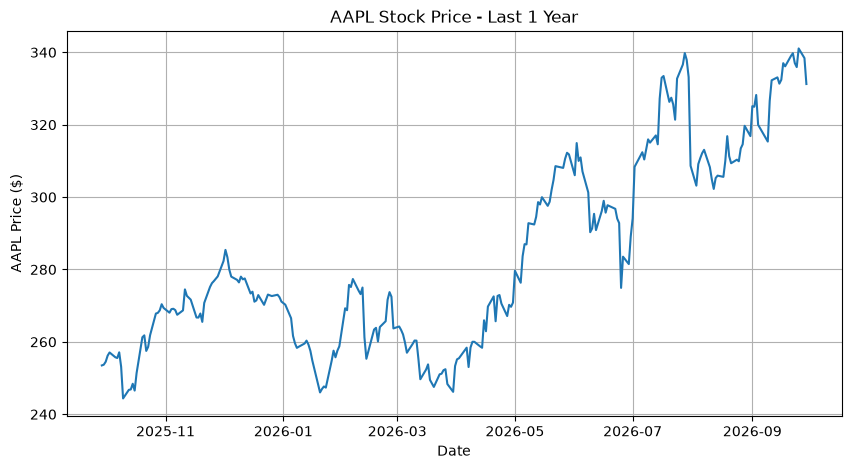

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(hist.index, hist["Close"])

plt.xlabel("Date")
plt.ylabel("AAPL Price ($)")
plt.title("AAPL Stock Price - Last 1 Year")
plt.grid(True)
plt.savefig("../figures/aapl_stock_price", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
S = hist["Close"].iloc[-1]

print(f"Current AAPL Price: ${S:.2f}")

Current AAPL Price: $331.24


In [15]:
daily_returns = hist["Close"].pct_change().dropna()

sigma = daily_returns.std() * np.sqrt(252)

print(f"Annualized Volatility: {sigma:.2%}")

Annualized Volatility: 24.59%


In [16]:
K = S
T = 30 / 365
r = 0.04

In [17]:
call = call_price(S, K, T, r, sigma)
put = put_price(S, K, T, r, sigma)

print(f"AAPL Price: ${S:.2f}")
print(f"Strike Price: ${K:.2f}")
print(f"Volatility: {sigma:.2%}")
print(f"Call Price: ${call:.2f}")
print(f"Put Price: ${put:.2f}")

AAPL Price: $331.24
Strike Price: $331.24
Volatility: 24.59%
Call Price: $9.85
Put Price: $8.76


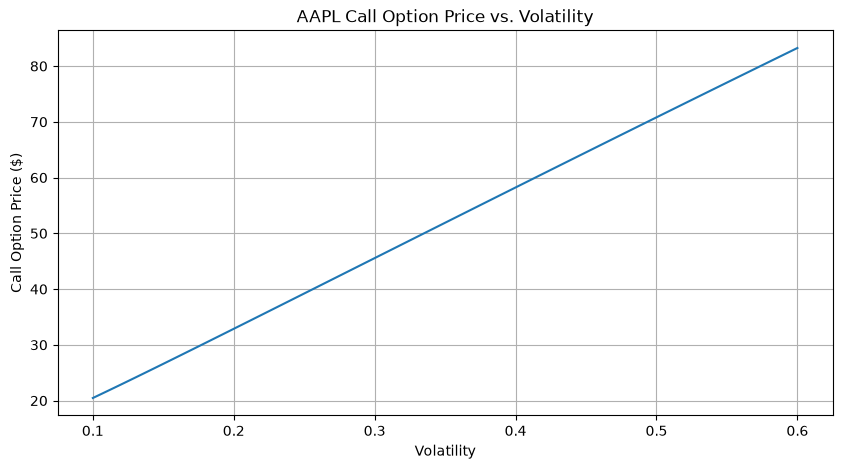

In [32]:
volatilities = np.linspace(0.10, 0.60, 100)

call_prices = [
    call_price(S, K, T, r, vol)
    for vol in volatilities
]

plt.figure(figsize=(10, 5))

plt.plot(volatilities, call_prices)

plt.xlabel("Volatility")
plt.ylabel("Call Option Price ($)")
plt.title("AAPL Call Option Price vs. Volatility")
plt.grid(True)
plt.savefig("../figures/volatility_sensitivity", dpi=300, bbox_inches="tight")
plt.show()

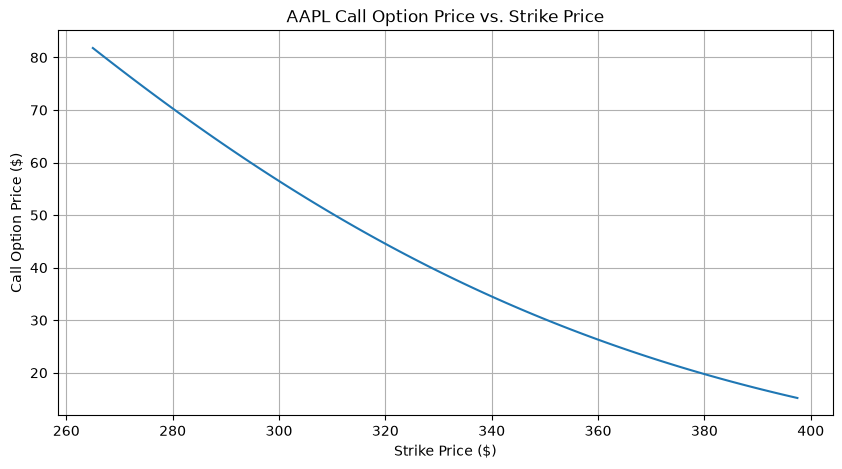

In [33]:
strike_prices = np.linspace(S * 0.8, S * 1.2, 100)

call_prices = [
    call_price(S, strike, T, r, sigma)
    for strike in strike_prices
]

plt.figure(figsize=(10, 5))

plt.plot(strike_prices, call_prices)

plt.xlabel("Strike Price ($)")
plt.ylabel("Call Option Price ($)")
plt.title("AAPL Call Option Price vs. Strike Price")
plt.grid(True)
plt.savefig("../figures/strike_sensitivity", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
expiration_dates = aapl.options

expiration_dates[:5]

('2026-09-30', '2026-10-02', '2026-10-05', '2026-10-07', '2026-10-09')

In [21]:
expiration = expiration_dates[0]

options = aapl.option_chain(expiration)

calls = options.calls
puts = options.puts

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL260930C00250000,2026-09-29 14:05:11+00:00,250.0,83.14,80.15,82.7,-5.910004,-6.636725,1.0,1,1.885743,True,REGULAR,USD
1,AAPL260930C00260000,2026-09-29 15:45:03+00:00,260.0,72.16,70.10,72.7,-6.479996,-8.240076,16.0,0,1.634767,True,REGULAR,USD
2,AAPL260930C00270000,2026-09-29 15:23:52+00:00,270.0,62.10,60.15,62.7,-5.700005,-8.407086,5.0,9,1.432620,True,REGULAR,USD
3,AAPL260930C00275000,2026-09-24 19:09:57+00:00,275.0,62.57,55.10,57.8,0.000000,0.000000,NaN,2,1.338870,True,REGULAR,USD
4,AAPL260930C00280000,2026-09-29 14:43:55+00:00,280.0,52.32,50.15,52.7,-5.270001,-9.150895,1.0,2,1.212895,True,REGULAR,USD


In [22]:
calls["distance_from_spot"] = abs(calls["strike"] - S)

atm_call = calls.loc[calls["distance_from_spot"].idxmin()]

atm_call

contractSymbol              AAPL260930C00330000
lastTradeDate         2026-09-29 16:31:23+00:00
strike                                    330.0
lastPrice                                  2.72
bid                                        2.69
ask                                        2.75
change                                    -6.17
percentChange                        -69.403824
volume                                   9091.0
openInterest                                277
impliedVolatility                      0.220955
inTheMoney                                 True
contractSize                            REGULAR
currency                                    USD
distance_from_spot                      1.23999
Name: 18, dtype: object

In [23]:
market_price = atm_call["lastPrice"]
strike = atm_call["strike"]

print(f"AAPL Price: ${S:.2f}")
print(f"Strike Price: ${strike:.2f}")
print(f"Market Call Price: ${market_price:.2f}")

AAPL Price: $331.24
Strike Price: $330.00
Market Call Price: $2.72


In [24]:
theoretical_price = call_price(
    S=S,
    K=strike,
    T=T,
    r=r,
    sigma=sigma
)

print(f"Theoretical Call Price: ${theoretical_price:.2f}")
print(f"Market Call Price:      ${market_price:.2f}")

Theoretical Call Price: $10.49
Market Call Price:      $2.72


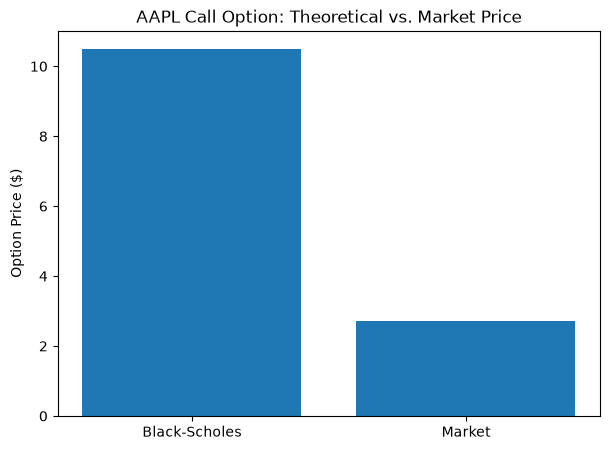

In [34]:
labels = ["Black-Scholes", "Market"]
prices = [theoretical_price, market_price]

plt.figure(figsize=(7, 5))

plt.bar(labels, prices)

plt.ylabel("Option Price ($)")
plt.title("AAPL Call Option: Theoretical vs. Market Price")
plt.savefig("../figures/ theoretical_vs_market", dpi=300, bbox_inches="tight")

plt.show()

## Conclusion

This analysis applied the Black-Scholes model to AAPL options using market data.

The project:

- Retrieved AAPL stock price data using `yfinance`
- Estimated annualized historical volatility
- Calculated theoretical European call and put option prices
- Visualized option price sensitivity to volatility and strike price
- Retrieved AAPL option chain data
- Compared the Black-Scholes theoretical price with the observed market price

The difference between theoretical and market prices demonstrates that option pricing depends on assumptions about volatility, interest rates, time to maturity, and other market factors.

In [27]:
S0 = S
mu = 0.04
sigma = sigma

T = 1.0          # 
steps = 252      #
n_paths = 100    # 

In [28]:
dt = T / steps

time = np.linspace(0, T, steps + 1)

paths = np.zeros((n_paths, steps + 1))
paths[:, 0] = S0

for t in range(1, steps + 1):
    z = np.random.standard_normal(n_paths)

    paths[:, t] = (
        paths[:, t - 1]
        * np.exp(
            (mu - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * z
        )
    )

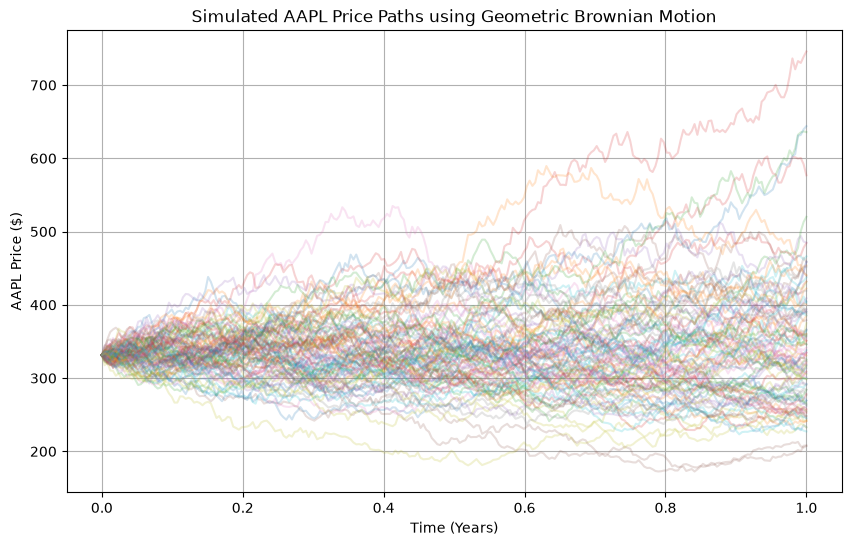

In [35]:
plt.figure(figsize=(10, 6))

for i in range(n_paths):
    plt.plot(time, paths[i], alpha=0.2)

plt.xlabel("Time (Years)")
plt.ylabel("AAPL Price ($)")
plt.title("Simulated AAPL Price Paths using Geometric Brownian Motion")
plt.grid(True)
plt.savefig("../figures/gbm_simulation.png", dpi=300, bbox_inches="tight")
plt.show()